[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/josterri/predicting-the-next-words-notebooks/blob/main/ch09_workbook.ipynb)

# Pre-training objectives: BERT, GPT and T5

A pre-training objective decides which words of a text become prediction
targets and which words each prediction may read. GPT predicts every word from
the words to its left, BERT predicts a random sample of hidden words from the
words on both sides, and T5's decoder reproduces hidden runs of words.

In [1]:
#@title Setup: run this cell first
import os
import re
import unicodedata
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

MIRROR_REF = "main"
TEXT_URL = f"https://raw.githubusercontent.com/josterri/predicting-the-next-words-notebooks/{MIRROR_REF}/data/pride_and_prejudice.txt"


def load_novel():
    """Pride and Prejudice as lowercase word tokens, one list per chapter."""
    if os.environ.get("PNW_TEXT"):
        text = open(os.environ["PNW_TEXT"], encoding="utf-8").read()
    else:
        try:
            text = urllib.request.urlopen(TEXT_URL).read().decode("utf-8")
        except OSError as e:
            raise RuntimeError(f"The text did not download from {TEXT_URL}: {e}. "
                               "Run this cell again; every cell below needs it.") from None
    chapters = re.split(r"(?m)^CHAPTER [IVXLC]+\.$", text)[1:]
    return [re.findall(r"[a-z]+(?:'[a-z]+)*", c.lower().replace("’", "'")) for c in chapters]


# A setting a cell refuses: Colab prints the one sentence, without the stack.
class Refused(Exception):
    _render_traceback_ = lambda self: [str(self)]  # noqa: E731


def need(ok, name, value, rule):
    if not ok: raise Refused(f"{name} is {repr(value)[:80]}, of type {type(value).__name__}: {rule}.")  # noqa: E701


def real(x):
    return isinstance(x, (int, float, np.integer, np.floating)) and not isinstance(x, (bool, np.bool_))


# A typed text split into lowercase words, as the novel is split: at every character other than
# a to z and the apostrophe. A digit or an accented letter would cut a word, so it is refused,
# composed or not: NFC joins a letter and its combining accent into one character.
def words(text):
    t = unicodedata.normalize("NFC", text).lower().replace("’", "'") if isinstance(text, str) else ""
    w, odd = re.findall(r"[a-z]+(?:'[a-z]+)*", t), re.search(r"[^\W_a-z]|[\u0300-\u036f]", t)
    need(2 <= len(w) <= 100 and not odd, "SENTENCE", text, "it must be 2 to 100 words in the letters a to z")
    return w


# The count and the noun, the noun plural unless the count is 1.
def counted(k, noun):
    return f"{k:,} {noun}" + ("" if k == 1 else "s")


# What the rule did to a rounded count: nothing, a rise to the floor of 1, or a cut to its cap.
def moved(raw, got, cap):
    return "" if got == raw else f", raised to {got}" if got > raw else f", cut to {got} = {cap}"


# The nearest whole number to x, a half going to the even one, as BERT's and T5's code round.
def whole(x): return round(round(x, 9))  # noqa: E704


def gen(seed):
    need(real(seed) and seed >= 0 and seed % 1 == 0, "SEED", seed, "it must be a whole number, 0 or more")
    return np.random.default_rng(int(seed))


# The positions a masked language model hides among n: round(rate × n), at least 1, at random.
def hide(n, rate, rng):
    need(real(rate) and 0.001 <= rate <= 1, "RATE", rate, "it must be a number from 0.001 to 1")
    return np.sort(rng.choice(n, max(1, whole(rate * n)), replace=False))


# n items cut at random into k runs of one item or more.
def runs(n, k, rng):
    return np.diff(np.r_[0, np.sort(rng.choice(n - 1, k - 1, replace=False)) + 1, n])


# T5's span corruption of the words w: c = round(rate × n) words, from 1 to n − 1, in
# s = round(c / span) runs, at least 1, at random places with a kept word between two runs.
# Returns the encoder input, the decoder target, the hidden positions and s.
def corrupt(w, rate, span, rng):
    need(real(span) and 1 <= span <= 10000, "SPAN", span, "it must be a number from 1 to 10,000")
    c = min(max(whole(rate * len(w)), 1), len(w) - 1)
    s = min(max(whole(c / span), 1), len(w) - c + 1)
    hid, kept = runs(c, s, rng), runs(len(w) - c + 2, s + 1, rng) - np.r_[1, np.zeros(s - 1, int), 1]
    enc, dec, at, i = [], [], [], 0
    for j in range(s):
        enc += w[i:i + kept[j]] + [f"<S{j + 1}>"]
        at += range(i + kept[j], i + kept[j] + hid[j])
        dec += [f"<S{j + 1}>"] + [w[a] for a in at[-hid[j]:]]
        i += kept[j] + hid[j]
    return enc + w[i:], dec + [f"<S{s + 1}>"], at, s


# A sentinel or [MASK] in code type, so that a page shows its brackets.
def tick(t): return f"`{t}`" if t[0] in "<[" else t  # noqa: E704


# The words a target reads: all of them when few, else the first two and the last three.
def reads(c):
    return "(the start)" if not c else " ".join(c) if len(c) <= 6 else f"{' '.join(c[:2])} … {' '.join(c[-3:])}"


def show_masked(w, at):
    copy = " ".join(tick("[MASK]") if i in at else x for i, x in enumerate(w))
    display(Markdown(f"**masked copy:** {copy}\n\n| position | target |\n| ---: | --- |\n" + "\n".join(f"| {i + 1} | {w[i]} |" for i in at)))


# The two sequences as a table, and each objective's targets as bars, sentinels hatched.
def show_spans(w, rate, span, seed):
    enc, dec, at, s = corrupt(w, rate, span, gen(seed))
    rows = [f"| {a} | {len(b)} | {' '.join(map(tick, b))} |" for a, b in (("encoder input", enc), ("decoder target", dec))]
    display(Markdown("| | tokens | text |\n| --- | ---: | --- |\n" + "\n".join(rows)))
    names, base, top = ["causal LM", "masked LM", "span corruption"], [len(w), len(hide(len(w), rate, gen(seed))), len(at)], [0, 0, s + 1]
    fig, ax = plt.subplots(figsize=(6, 3.5), layout="tight")  # laid out so that no label is cut off
    ax.barh(names, base, color="C0", edgecolor="C0", label="words of the sentence")
    bars = ax.barh(names, top, left=base, color="w", edgecolor="C0", hatch="///", label="sentinels")
    ax.bar_label(bars, labels=[f"{b + x:,}" for b, x in zip(base, top)], padding=3)
    ax.set(xlabel="targets: loss terms from one pass over the sentence", ylim=(2.5, -0.5), xlim=(0, 1.15 * max(len(w), len(at) + s + 1)))
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True, steps=[1, 2, 5, 10]))
    ax.legend(loc="lower left", bbox_to_anchor=(0, 1), ncol=2, frameon=False)
    plt.show()


# BERT's rule on the novel at rate 0.15: each hidden position shows [MASK], a random word of the
# novel or its own word, with the shares in split. Per 1,000 tokens: the targets, and the
# positions whose input shows [MASK], another word and the target's own word.
def bert(split, seed=0):
    ok = isinstance(split, (tuple, list)) and len(split) == 3 and all(real(x) and 0 <= x <= 1 for x in split)
    need(ok and abs(sum(split) - 1) < 1e-9, "SPLIT", split, "it must be three numbers from 0 to 1 summing to 1")
    rng = np.random.default_rng(seed)
    at = np.concatenate([512 * j + hide(len(q), 0.15, rng) for j, q in enumerate(seqs)])
    kind = np.searchsorted(np.cumsum(split[:2]), rng.random(len(at)), side="right")
    shown = np.where(kind == 1, rng.integers(len(types), size=len(at)), ids[at])
    mask, own = (kind == 0).sum(), ((kind != 0) & (shown == ids[at])).sum()
    return [1000 * x / len(tokens) for x in (len(at), mask, len(at) - mask - own, own)]


chapters = load_novel()
tokens = [w for c in chapters for w in c]
types, ids = np.unique(tokens, return_inverse=True)
seqs = [tokens[i:i + 512] for i in range(0, len(tokens), 512)]
# What steps 1 and 2 last ran with, first the novel's first sentence; the cells below read these.
sentence, rate, seed = " ".join(chapters[0][:23]), 0.15, 0
print(f"{len(chapters)} chapters, {len(tokens):,} tokens, {len(types):,} word types, {len(seqs)} sequences.")

61 chapters, 122,174 tokens, 6,314 word types, 239 sequences.


## 1. Causal language modelling makes every word a target

A causal language model predicts each word of a text from the words before it,
and the first word from the start of the text alone. Run the cell, then put a
sentence of your own into `SENTENCE` and run it again. How many targets does
the sentence give, and how many words does its last target read?

In [2]:
SENTENCE = "it is a truth universally acknowledged that a single man in possession of a good fortune must be in want of a wife"
w = words(SENTENCE)
display(Markdown("| t | target | words it reads | count |\n| ---: | --- | --- | ---: |\n"
                 + "\n".join(f"|{t + 1}|{x}|{reads(w[:t])}|{t}|" for t, x in enumerate(w))))
sentence = SENTENCE

| t | target | words it reads | count |
| ---: | --- | --- | ---: |
|1|it|(the start)|0|
|2|is|it|1|
|3|a|it is|2|
|4|truth|it is a|3|
|5|universally|it is a truth|4|
|6|acknowledged|it is a truth universally|5|
|7|that|it is a truth universally acknowledged|6|
|8|a|it is … universally acknowledged that|7|
|9|single|it is … acknowledged that a|8|
|10|man|it is … that a single|9|
|11|in|it is … a single man|10|
|12|possession|it is … single man in|11|
|13|of|it is … man in possession|12|
|14|a|it is … in possession of|13|
|15|good|it is … possession of a|14|
|16|fortune|it is … of a good|15|
|17|must|it is … a good fortune|16|
|18|be|it is … good fortune must|17|
|19|in|it is … fortune must be|18|
|20|want|it is … must be in|19|
|21|of|it is … be in want|20|
|22|a|it is … in want of|21|
|23|wife|it is … want of a|22|

### Solution

In [3]:
w = words(SENTENCE)
display(Markdown(f"Split as the novel is, at spaces, hyphens and punctuation, the sentence holds "
                 f"{len(w)} words and gives {len(w)} targets: \"{w[0]}\" is predicted from the "
                 f"start of the text, \"{w[-1]}\" from {counted(len(w) - 1, 'word')} before it."))

Split as the novel is, at spaces, hyphens and punctuation, the sentence holds 23 words and gives 23 targets: "it" is predicted from the start of the text, "wife" from 22 words before it.

## 2. Masked language modelling hides a random sample of positions

A masked language model hides a share `RATE` of the positions, drawn at
random from the seed `SEED`, behind `[MASK]`, and predicts each hidden word
from the words left visible, on either side of it. Run the cell, then
change `SEED` and run it again. How many targets does the masked copy give,
and how many words can each target read?

In [4]:
RATE = 0.15
SEED = 0
w = words(sentence)
show_masked(w, hide(len(w), RATE, gen(SEED)))
rate, seed = RATE, SEED

**masked copy:** it is a truth universally acknowledged that a single man in `[MASK]` of a `[MASK]` fortune must `[MASK]` in want of a wife

| position | target |
| ---: | --- |
| 12 | possession |
| 15 | good |
| 18 | be |

### Solution

In [5]:
n = len(words(sentence))
k, sets = len(hide(n, RATE, gen(SEED))), {tuple(hide(n, RATE, gen(i))) for i in range(10)}
display(Markdown(f"{RATE} × {n} = {RATE * n:.9g}, rounded half to even and at least 1, hides {k} "
                 f"of the {n} words, a share of {k / n:.2f}, each a target that reads the "
                 f"{counted(n - k, 'visible word')} on both sides of it. Seeds 0 to 9 give "
                 f"{counted(len(sets), 'different set')} of {counted(k, 'hidden position')}."))

0.15 × 23 = 3.45, rounded half to even and at least 1, hides 3 of the 23 words, a share of 0.13, each a target that reads the 20 visible words on both sides of it. Seeds 0 to 9 give 10 different sets of 3 hidden positions.

## 3. Span corruption hides runs of words behind sentinels

T5 hides a share `RATE` of the sentence in runs of `SPAN` words on average,
puts one sentinel such as `<S1>` in place of each run, and trains its decoder
to write each run back after its sentinel. Run the cell, then set `SPAN` to 1
and run it again. How many targets does each objective give for the sentence,
and how many tokens does the encoder read?

| | tokens | text |
| --- | ---: | --- |
| encoder input | 21 | it is a truth universally acknowledged that a single man in possession of a good fortune must `<S1>` of a wife |
| decoder target | 5 | `<S1>` be in want `<S2>` |

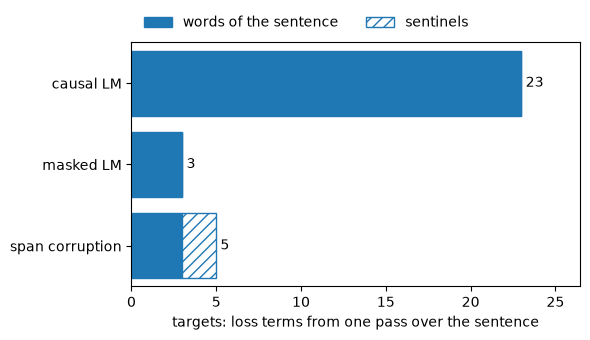

In [6]:
SPAN = 3
show_spans(words(sentence), rate, SPAN, seed)

### Solution

In [7]:
w, n = words(sentence), len(words(sentence))
enc, dec, at, s = corrupt(w, rate, SPAN, gen(seed))
c, k = len(at), len(hide(n, rate, gen(seed)))
sets = {tuple(corrupt(w, rate, SPAN, gen(i))[2]) for i in range(10)}
cn, sn = moved(whole(rate * n), c, "n − 1"), moved(whole(c / SPAN), s, "n − c + 1")
display(Markdown(f"The {n} words give {n} targets to the causal LM, {k} to the masked LM and "
                 f"{len(dec)} to span corruption: {counted(c, 'hidden word')} and "
                 f"{counted(s + 1, 'sentinel')}. The hidden words number round({rate} × {n}) = "
                 f"{whole(rate * n)}{cn}, and the runs round({c} / {SPAN}) = "
                 f"{whole(c / SPAN)}{sn}, a mean run length of {c / s:.2f}. The encoder reads "
                 f"{len(enc)} tokens; seeds 0 "
                 f"to 9 give {counted(len(sets), 'different set')} of hidden positions."))

The 23 words give 23 targets to the causal LM, 3 to the masked LM and 5 to span corruption: 3 hidden words and 2 sentinels. The hidden words number round(0.15 × 23) = 3, and the runs round(3 / 3) = 1, a mean run length of 3.00. The encoder reads 21 tokens; seeds 0 to 9 give 6 different sets of hidden positions.

## Appendix. Loss terms per 1,000 tokens against the masking rate

Each objective sums −log P over its targets in a sequence of T tokens.

- Causal LM: L = −Σ log P(wₜ | w₁ … wₜ₋₁), over t = 1 … T, so T targets.
- Masked LM: k = round(r·T) positions chosen at random, at least 1, and
  L = −Σ log P(wₘ | x̃), over the k hidden positions m, so k targets. x̃ is the
  input the model reads: the text with `[MASK]` at every hidden position, or,
  under BERT's rule, with `[MASK]` there with probability 0.8, a random word
  with 0.1 and the word itself with 0.1. All k positions stay targets.
- Span corruption: c = round(r·T) tokens, from 1 to T − 1, in s = round(c / μ)
  runs of mean length μ, at least 1, and at most T − c + 1, since a kept token
  separates two runs. The encoder reads the T − c kept tokens and s sentinels;
  the decoder writes c + s + 1 tokens, each a target: the c hidden tokens, a
  sentinel before each run and one after the last.

round(x) is the nearest whole number, a half going to the even one. Per 1,000
tokens the causal LM has 1,000 targets, the masked LM about 1,000·r and span
corruption about 1,000·r·(1 + 1/μ) + 1,000/T. On the novel cut into sequences
of T = 512 tokens, for r from 0.05 to 0.5 and μ = 3:

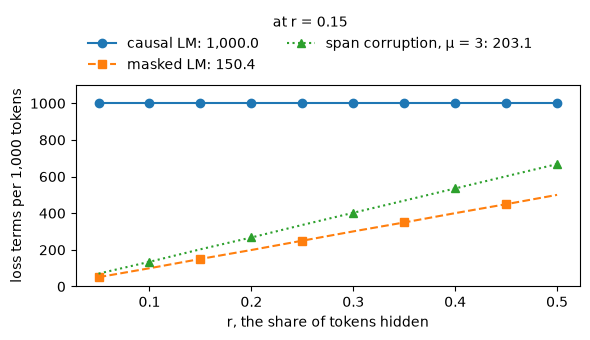

In [8]:
# Loss terms per 1,000 tokens of the novel at each rate: every token under the causal LM, the
# hidden positions under the masked LM, the decoder target under span corruption with μ = 3.
rates, rng = np.linspace(0.05, 0.5, 10), np.random.default_rng(0)
pairs = [np.sum([(len(hide(len(q), r, rng)), len(corrupt(q, r, 3, rng)[1])) for q in seqs], 0) for r in rates]
terms = 1000 / len(tokens) * np.c_[np.full(len(rates), len(tokens)), pairs]
fig, ax = plt.subplots(figsize=(6, 3.5), layout="tight")
for y, name, style, every in zip(terms.T, ("causal LM", "masked LM", "span corruption, μ = 3"), ("o-", "s--", "^:"), (1, (0, 2), (1, 2))):
    ax.plot(rates, y, style, markevery=every, label=f"{name}: {y[2]:,.1f}")
ax.set(xlabel="r, the share of tokens hidden", ylabel="loss terms per 1,000 tokens", ylim=(0, 1100))
ax.legend(loc="lower left", bbox_to_anchor=(0, 1), ncol=2, frameon=False, title="at r = 0.15")
plt.show()

**Exercise.** Set `SPLIT`, the shares of `[MASK]`, a random word and the word
itself, to (1, 0, 0), then to (0.8, 0.1, 0.1), and rerun the cell each time.
How many targets per 1,000 tokens of the novel does each split give, and at
how many of them does the input show the word the model must predict?

In [9]:
SPLIT = (0.8, 0.1, 0.1)

t, m, other, own = bert(SPLIT)
print(f"{t:.1f} targets per 1,000 tokens; the input shows [MASK] at {m:.1f}, another word at "
      f"{other:.1f} and the hidden word itself at {own:.1f}")

150.4 targets per 1,000 tokens; the input shows [MASK] at 120.8, another word at 15.1 and the hidden word itself at 14.6


### Solution

In [10]:
# Devlin et al. 2019, App. C.2, Table 8: the six mixes BERT pre-trained. Its columns are MASK,
# SAME and RND; here each mix is ([MASK], a random word, the word itself).
mixes = [(0.8, 0.1, 0.1), (1, 0, 0), (0.8, 0.2, 0), (0.8, 0, 0.2), (0, 0.8, 0.2), (0, 1, 0)]
mine = bert(SPLIT)
res = {**{mx: bert(mx) for mx in mixes}, tuple(SPLIT): mine}
rows = [f"| {mx} | " + " | ".join(f"{v:.1f}" for v in r) + " |" for mx, r in res.items()]
display(Markdown("| shares | targets | `[MASK]` | another word | the hidden word itself |\n"
                 "|---|---:|---:|---:|---:|\n" + "\n".join(rows)))
spread = [bert(SPLIT, seed=i)[3] for i in range(5)]
display(Markdown(f"Every split gives {mine[0]:.1f} targets per 1,000 tokens: a hidden position "
                 f"stays a target whatever the input shows there. Under {tuple(SPLIT)} the input "
                 f"shows the hidden word itself at {mine[3]:.1f} per 1,000 tokens, a share of "
                 f"{mine[3] / 1000:.4f} of all positions, and seeds 0 to 4 put it between "
                 f"{min(spread):.1f} and {max(spread):.1f}."))

| shares | targets | `[MASK]` | another word | the hidden word itself |
|---|---:|---:|---:|---:|
| (0.8, 0.1, 0.1) | 150.4 | 120.8 | 15.1 | 14.6 |
| (1, 0, 0) | 150.4 | 150.4 | 0.0 | 0.0 |
| (0.8, 0.2, 0) | 150.4 | 120.8 | 29.6 | 0.0 |
| (0.8, 0, 0.2) | 150.4 | 120.8 | 0.0 | 29.6 |
| (0, 0.8, 0.2) | 150.4 | 0.0 | 120.7 | 29.7 |
| (0, 1, 0) | 150.4 | 0.0 | 150.4 | 0.0 |

Every split gives 150.4 targets per 1,000 tokens: a hidden position stays a target whatever the input shows there. Under (0.8, 0.1, 0.1) the input shows the hidden word itself at 14.6 per 1,000 tokens, a share of 0.0146 of all positions, and seeds 0 to 4 put it between 14.6 and 15.3.